<>:172: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:172: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11772\1072861640.py:172: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title("Estimación de $\pi$ mediante la serie de Leibniz")


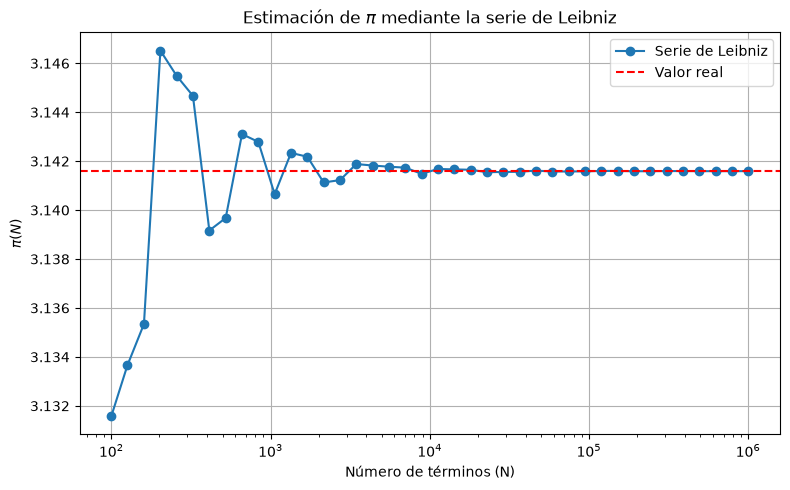

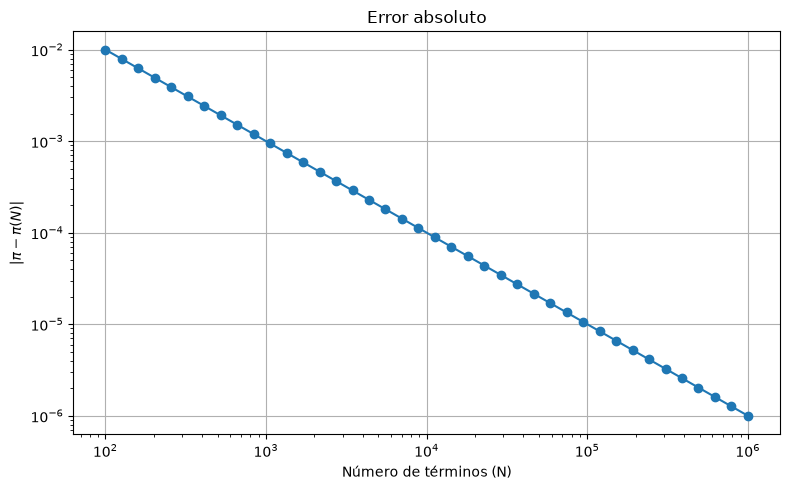

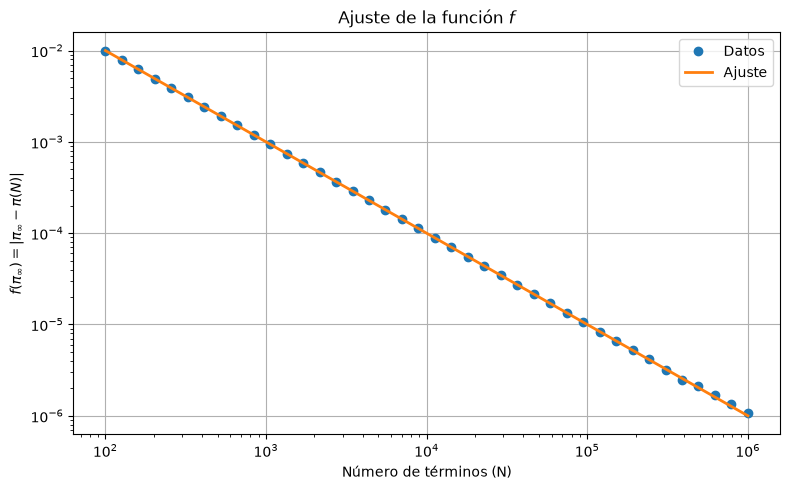

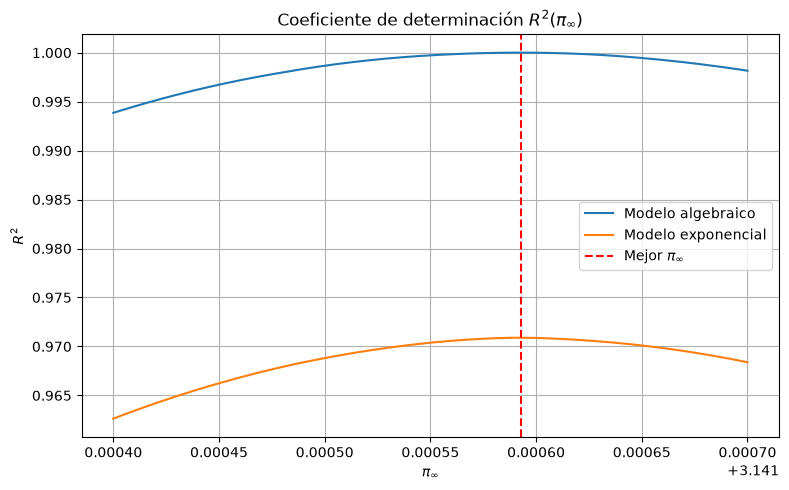


RESULTADOS
Valor real de π          : 3.1415926536
π∞ estimado              : 3.1415927285
Modelo de convergencia   : Algebraico
Coeficiente R²           : 1.00000000
Error absoluto           : 7.4895864177e-08
Error relativo           : 2.3840094002e-08
Error porcentual         : 0.00000238 %


In [1]:
# Punto 5 - Serie de Leibniz para calcular π
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================================
# SERIE DE LEIBNIZ
# ==========================================================

def leibniz_pi(N):
    k = np.arange(N)
    return 4*np.sum(((-1)**k)/(2*k+1))

# ==========================================================
# MODELOS
# ==========================================================

def modelo_algebraico(N,A,alpha):
    return A/(N**alpha)

def modelo_exponencial(N,A,lamb):
    return A*np.exp(-lamb*N)

# ==========================================================
# R²
# ==========================================================

def calcular_r2(y,y_ajuste):

    ss_res=np.sum((y-y_ajuste)**2)
    ss_tot=np.sum((y-np.mean(y))**2)

    return 1-ss_res/ss_tot

# ==========================================================
# AJUSTE
# ==========================================================

def ajustar_modelo(N,f):

    resultados={}

    try:

        p_alg,_=curve_fit(
            modelo_algebraico,
            N,
            f,
            p0=[1,1],
            maxfev=10000
        )

        ajuste_alg=modelo_algebraico(N,*p_alg)

        r2_alg=calcular_r2(f,ajuste_alg)

    except:

        p_alg=None
        ajuste_alg=None
        r2_alg=-np.inf

    resultados["algebraico"]={
        "parametros":p_alg,
        "ajuste":ajuste_alg,
        "r2":r2_alg
    }

    try:

        p_exp,_=curve_fit(
            modelo_exponencial,
            N,
            f,
            p0=[1,1e-6],
            maxfev=10000
        )

        ajuste_exp=modelo_exponencial(N,*p_exp)

        r2_exp=calcular_r2(f,ajuste_exp)

    except:

        p_exp=None
        ajuste_exp=None
        r2_exp=-np.inf

    resultados["exponencial"]={
        "parametros":p_exp,
        "ajuste":ajuste_exp,
        "r2":r2_exp
    }

    return resultados

# ==========================================================
# BÚSQUEDA DEL MEJOR π∞
# ==========================================================

def buscar_mejor_pi(N,pi_N):

    pi_inf_posibles=np.linspace(3.1414,3.1417,1500)

    r2_alg=[]
    r2_exp=[]

    parametros_alg=[]
    parametros_exp=[]

    for pi_inf in pi_inf_posibles:

        f=np.abs(pi_inf-pi_N)

        resultados=ajustar_modelo(N,f)

        r2_alg.append(resultados["algebraico"]["r2"])
        r2_exp.append(resultados["exponencial"]["r2"])

        parametros_alg.append(resultados["algebraico"]["parametros"])
        parametros_exp.append(resultados["exponencial"]["parametros"])

    r2_alg=np.array(r2_alg)
    r2_exp=np.array(r2_exp)

    if np.max(r2_alg)>=np.max(r2_exp):

        indice=np.argmax(r2_alg)

        return{
            "modelo":"Algebraico",
            "tipo":"algebraico",
            "pi_inf":pi_inf_posibles[indice],
            "r2":r2_alg[indice],
            "parametros":parametros_alg[indice],
            "r2_alg":r2_alg,
            "r2_exp":r2_exp,
            "pi_inf_posibles":pi_inf_posibles
        }

    indice=np.argmax(r2_exp)

    return{
        "modelo":"Exponencial",
        "tipo":"exponencial",
        "pi_inf":pi_inf_posibles[indice],
        "r2":r2_exp[indice],
        "parametros":parametros_exp[indice],
        "r2_alg":r2_alg,
        "r2_exp":r2_exp,
        "pi_inf_posibles":pi_inf_posibles
    }

# ==========================================================
# GRÁFICAS
# ==========================================================

def graficar_pi(N,pi_N):

    plt.figure(figsize=(8,5))

    plt.plot(N,pi_N,'o-',label='Serie de Leibniz')

    plt.axhline(np.pi,color='red',ls='--',label='Valor real')

    plt.xscale("log")

    plt.xlabel("Número de términos (N)")
    plt.ylabel(r"$\pi(N)$")
    plt.title("Estimación de $\pi$ mediante la serie de Leibniz")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig("LeibnizPi.png",dpi=300)
    plt.show()

def graficar_error(N,pi_N):

    error=np.abs(np.pi-pi_N)

    plt.figure(figsize=(8,5))

    plt.loglog(N,error,'o-')

    plt.xlabel("Número de términos (N)")
    plt.ylabel(r"$|\pi-\pi(N)|$")
    plt.title("Error absoluto")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig("ErrorLeibniz.png",dpi=300)

    plt.show()


# Número de términos de la serie
N = np.unique(np.logspace(2, 6, 40, dtype=int))

# Calcular π(N)
pi_N = np.array([leibniz_pi(n) for n in N])

# ----------------------------------------------------------
# Gráfica π(N)
# ----------------------------------------------------------

graficar_pi(N, pi_N)

# ----------------------------------------------------------
# Gráfica del error
# ----------------------------------------------------------

graficar_error(N, pi_N)

# ----------------------------------------------------------
# Buscar mejor π∞
# ----------------------------------------------------------

resultado = buscar_mejor_pi(N, pi_N)

pi_inf = resultado["pi_inf"]
modelo = resultado["modelo"]
r2 = resultado["r2"]
parametros = resultado["parametros"]
tipo = resultado["tipo"]

# ----------------------------------------------------------
# Calcular f(π∞)
# ----------------------------------------------------------

f = np.abs(pi_inf - pi_N)

if tipo == "algebraico":
    ajuste = modelo_algebraico(N, *parametros)
else:
    ajuste = modelo_exponencial(N, *parametros)

# ----------------------------------------------------------
# Gráfica del ajuste
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.loglog(
    N,
    f,
    'o',
    label='Datos'
)

plt.loglog(
    N,
    ajuste,
    '-',
    linewidth=2,
    label='Ajuste'
)

plt.xlabel("Número de términos (N)")
plt.ylabel(r"$f(\pi_\infty)=|\pi_\infty-\pi(N)|$")
plt.title("Ajuste de la función $f$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("FuncionLeibniz.png", dpi=300)

plt.show()

# ----------------------------------------------------------
# Gráfica de R²
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    resultado["pi_inf_posibles"],
    resultado["r2_alg"],
    label="Modelo algebraico"
)

plt.plot(
    resultado["pi_inf_posibles"],
    resultado["r2_exp"],
    label="Modelo exponencial"
)

plt.axvline(
    pi_inf,
    color='red',
    linestyle='--',
    label=r'Mejor $\pi_\infty$'
)

plt.xlabel(r"$\pi_\infty$")
plt.ylabel(r"$R^2$")
plt.title(r"Coeficiente de determinación $R^2(\pi_\infty)$")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("R2Leibniz.png", dpi=300)

plt.show()

# ----------------------------------------------------------
# Resultados finales
# ----------------------------------------------------------

error_abs = abs(np.pi - pi_inf)
error_rel = error_abs / np.pi
error_porcentual = error_rel * 100

print("\n" + "="*60)
print("RESULTADOS")
print("="*60)

print(f"Valor real de π          : {np.pi:.10f}")
print(f"π∞ estimado              : {pi_inf:.10f}")
print(f"Modelo de convergencia   : {modelo}")
print(f"Coeficiente R²           : {r2:.8f}")
print(f"Error absoluto           : {error_abs:.10e}")
print(f"Error relativo           : {error_rel:.10e}")
print(f"Error porcentual         : {error_porcentual:.8f} %")

print("="*60)